# Statistical and specialty plots

Some questions need more than a line or a bar. This notebook covers the statistical plots used to
show spread and relationships — box, scatter, bubble, regression — plus two specialty displays: a
waffle grid for proportions and a word-frequency chart for text. It uses Gapminder and the USGS
earthquake feed.

## Learning objectives

By the end of this notebook you will be able to:

- show a distribution's spread with a box plot;
- encode a third variable with bubble size and a fourth with colour;
- add a fitted trend line to a scatter plot;
- build a waffle grid to display proportions honestly;
- summarise free text with a word-frequency chart.

## Concept

A **box plot** shows the median, the quartiles, and the extreme values of each group, so it
compares both level and spread in a way a bar of means cannot. **Scatter** plots show the
relationship between two numeric variables; **bubble** charts add size as a third encoding, and
colour can add a category or a fourth variable. **Regression** plots add a fitted line, with care:
a line assumes a linear relationship and a correlation does not justify a causal reading.

A **pie** chart is familiar but hard to read beyond two or three slices because people compare
angles poorly. A **waffle** grid — unit squares in a ten-by-ten block — makes small proportions
visually comparable and avoids the angle problem. For text, a **word-frequency** chart counts the
most common tokens after simple cleaning; a full word cloud is decorative and makes a word's size
hard to map to its exact count, so a horizontal bar of the top terms is more precise.

Encoding choices matter. Size comparisons work only if area (not radius) is proportional; colour
palettes should be perceptually uniform and colour-blind safe.

## Worked example

### Load data

In [1]:
import sys
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.insert(0, str(Path.cwd().parent))
from ds_practice import load_gapminder, load_usgs_quakes, set_seed, set_theme

set_seed(42)
set_theme()
gap = load_gapminder()
latest = gap[gap["year"] == gap["year"].max()]
print("countries:", len(latest))

countries: 142


### Box plot: spread of life expectancy

The boxes show that Africa's median is lower and its spread wider than the other continents.

/tmp/ipykernel_120633/1315478199.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=order, showfliers=True)


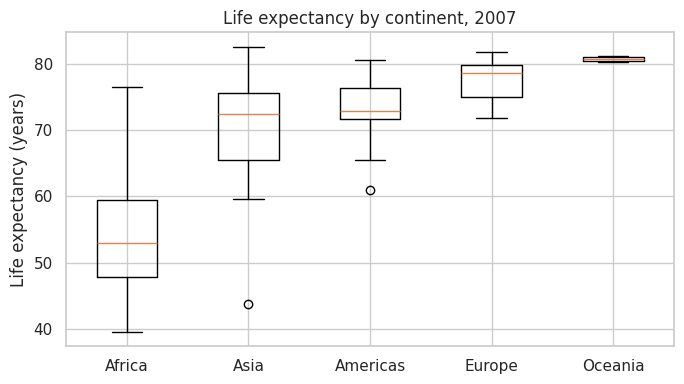

In [2]:
order = latest.groupby("continent")["lifeExp"].median().sort_values().index.tolist()
data = [latest.loc[latest["continent"] == c, "lifeExp"] for c in order]

fig, ax = plt.subplots(figsize=(7, 4))
ax.boxplot(data, labels=order, showfliers=True)
ax.set_title("Life expectancy by continent, 2007")
ax.set_ylabel("Life expectancy (years)")
fig.tight_layout()
plt.show()

### Scatter and regression

Life expectancy rises with income, but the relationship is curved and the variance grows with GDP,
so we work on a log income axis and add a trend line.

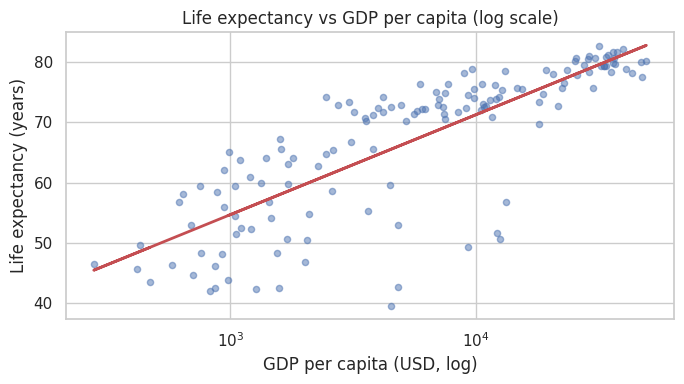

correlation (lifeExp vs log GDP): 0.809


In [3]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(latest["gdpPercap"], latest["lifeExp"], alpha=0.5, s=20, color="#4c72b0")
ax.set_xscale("log")
log_x = np.log10(latest["gdpPercap"])
slope, intercept = np.polyfit(log_x, latest["lifeExp"], 1)
ax.plot(latest["gdpPercap"], slope * log_x + intercept, color="#c44e52", linewidth=2)
ax.set_title("Life expectancy vs GDP per capita (log scale)")
ax.set_xlabel("GDP per capita (USD, log)")
ax.set_ylabel("Life expectancy (years)")
fig.tight_layout()
plt.show()
print("correlation (lifeExp vs log GDP):", round(latest["lifeExp"].corr(log_x), 3))

### Bubble chart

Adding population as bubble size and continent as colour enriches the same scatter. Sizes are
scaled so the largest bubble is readable.

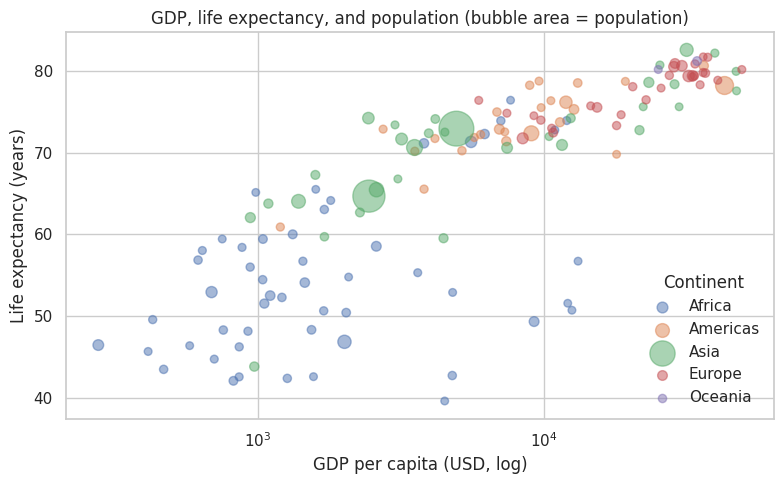

In [4]:
fig, ax = plt.subplots(figsize=(8, 5))
sizes = 30 + 600 * (latest["pop"] / latest["pop"].max())
for name, group in latest.groupby("continent"):
    ax.scatter(group["gdpPercap"], group["lifeExp"],
               s=sizes[group.index], alpha=0.5, label=name)
ax.set_xscale("log")
ax.set_title("GDP, life expectancy, and population (bubble area = population)")
ax.set_xlabel("GDP per capita (USD, log)")
ax.set_ylabel("Life expectancy (years)")
ax.legend(title="Continent", frameon=False, loc="lower right")
fig.tight_layout()
plt.show()

### Waffle grid

Each cell is one percent of world population. Squares are shaded by continent, so the proportions
can be compared by counting rather than by judging angles.

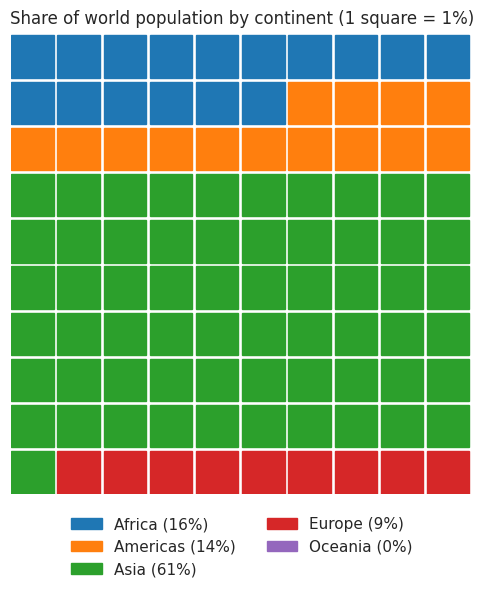

In [5]:
shares = (latest.groupby("continent")["pop"].sum() / latest["pop"].sum() * 100).round().astype(int)
# adjust rounding so the cells total exactly 100
diff = 100 - shares.sum()
shares.iloc[0] += diff

cells = []
for continent, count in shares.items():
    cells.extend([continent] * count)
palette = dict(zip(shares.index, plt.cm.tab10.colors))

fig, ax = plt.subplots(figsize=(6, 6))
for i, continent in enumerate(cells):
    row, col = divmod(i, 10)
    ax.add_patch(plt.Rectangle((col, 9 - row), 0.92, 0.92, color=palette[continent]))
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.set_aspect("equal")
ax.axis("off")
ax.set_title("Share of world population by continent (1 square = 1%)")
handles = [plt.Rectangle((0, 0), 1, 1, color=palette[c]) for c in shares.index]
ax.legend(handles, [f"{c} ({shares[c]}%)" for c in shares.index],
          loc="upper center", bbox_to_anchor=(0.5, -0.02), ncol=2, frameon=False)
plt.show()

### Word frequency from text

The USGS `place` column is free text. After lowercasing and stripping punctuation, we count the
most common words and show them as a horizontal bar — a precise alternative to a word cloud.

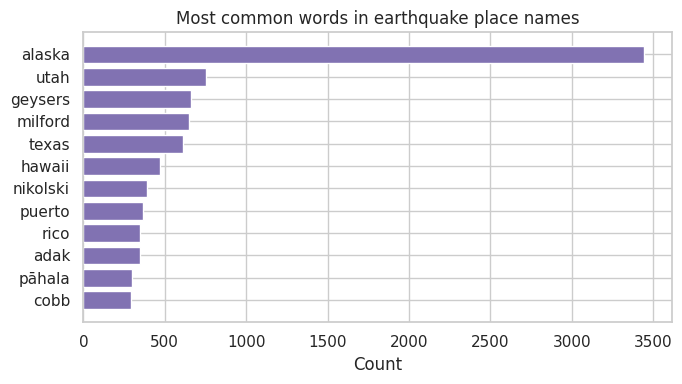

In [6]:
quakes = load_usgs_quakes()
text = " ".join(quakes["place"].dropna().astype(str).str.lower())
cleaned = "".join(ch if ch.isalpha() or ch.isspace() else " " for ch in text)
stop = {"of", "the", "km", "and", "a", "in", "at"}
words = [w for w in cleaned.split() if len(w) > 3 and w not in stop]
top = Counter(words).most_common(12)
labels, counts = zip(*top)

fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(list(labels)[::-1], list(counts)[::-1], color="#8172b2")
ax.set_title("Most common words in earthquake place names")
ax.set_xlabel("Count")
fig.tight_layout()
plt.show()

## Exercises

1. **Pie versus waffle.** Draw a pie chart of the same population shares and explain in two
   sentences which chart communicated the smallest continent's share more clearly.
2. **Bubble scaling.** Redraw the bubble chart using radius proportional to population instead of
   area. Describe how the visual impression changes and why area is the better encoding.
3. **Depth distribution.** Using the USGS data, draw a box plot of earthquake magnitude (`mag`) by
   `magType` for the five most common types, and note any group with very few observations.

## Limitations

A regression line on observational data is a summary, not a causal model, and it can mislead when
the relationship is non-linear. Box plots hide the number of observations and the shape of the
distribution, so always pair them with `count`. Bubble charts become unreadable beyond a few dozen
points. The word-frequency chart ignores word order and meaning, so "south" and "of" carry no
context; proper text analysis needs tokenisation and stop-word handling beyond this demonstration.